In [1]:
# Practice Program - Week 1 

import pandas as pd 
import random

names = ["Alice", "Bob", "Charlie", "Emma", "John"]

data = {
    "Name" : [random.choice(names) for _ in range(100)],
    "Age" : [random.randint(18, 30) for _ in range(100)],
    "Marks" : [random.randint(40, 100) for _ in range(100)],
    "Attendance" : [random.randint(60, 100) for _ in range(100)]
}

df = pd.DataFrame(data)
df.to_csv("random_students.csv", index=False)
print(df.head())
    
    

      Name  Age  Marks  Attendance
0     John   26     90          99
1     John   28     57          65
2  Charlie   30     46          92
3     John   29     44          62
4    Alice   20     47          93


In [2]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Name        100 non-null    object
 1   Age         100 non-null    int64 
 2   Marks       100 non-null    int64 
 3   Attendance  100 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 3.3+ KB
None


In [3]:
print(df.isnull().sum())

Name          0
Age           0
Marks         0
Attendance    0
dtype: int64


In [4]:
# Introduce some missing values for demonstration
df.loc[5, "Age"] = None
df.loc[12, "Age"] = None

df.loc[8, "Marks"] = None
df.loc[20, "Marks"] = None

df.to_csv("random_students.csv", index=False)


In [5]:
# find missing values in age column
# median() - calculate middle value of age column 
# df["Age"] = df["Age"].fillna(df["Age"].median(), inplace=True)
df["Age"] = df["Age"].fillna(df["Age"].median())
print(df.head())
print(df["Age"].isnull().sum())


      Name   Age  Marks  Attendance
0     John  26.0   90.0          99
1     John  28.0   57.0          65
2  Charlie  30.0   46.0          92
3     John  29.0   44.0          62
4    Alice  20.0   47.0          93
0


In [6]:
# mode()[0] - find most frequently occurred value, gets the first mode  
df["Marks"] = df["Marks"].fillna(df["Marks"].mean())

In [7]:
# df.drop(columns=["Attendance"], inplace=True)

In [8]:
# summary statistics
print("\n Summary Statistics")
print(df.describe())


 Summary Statistics
             Age       Marks  Attendance
count  100.00000  100.000000  100.000000
mean    24.03000   71.979592   79.770000
std      3.82299   19.260563   11.673033
min     18.00000   41.000000   61.000000
25%     21.00000   52.000000   70.500000
50%     23.00000   73.000000   80.000000
75%     27.25000   90.000000   89.000000
max     30.00000  100.000000  100.000000


In [9]:
print("\nAvg age: ", df["Age"].mean())


Avg age:  24.03


In [10]:
print(df.groupby("Age")["Attendance"].mean())


Age
18.0    75.125000
19.0    83.000000
20.0    84.571429
21.0    72.571429
22.0    80.272727
23.0    76.538462
24.0    79.500000
25.0    72.750000
26.0    78.714286
27.0    78.333333
28.0    84.428571
29.0    82.818182
30.0    87.000000
Name: Attendance, dtype: float64


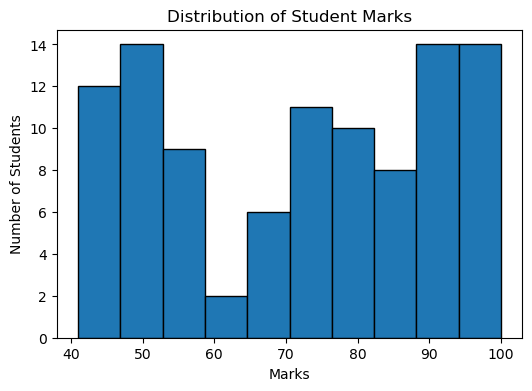

In [11]:
# chart 1
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df["Marks"], bins=10, edgecolor="black")

plt.title("Distribution of Student Marks")
plt.xlabel("Marks")
plt.ylabel("Number of Students")

plt.show()

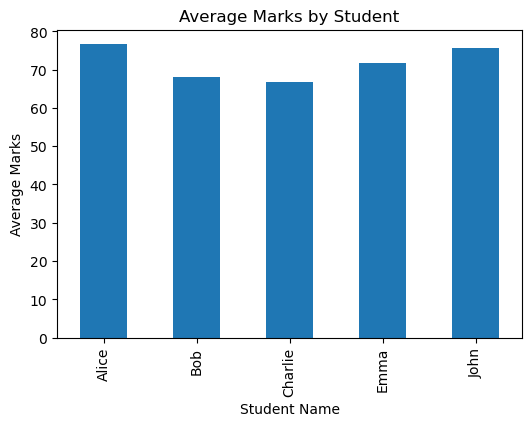

In [12]:
# chart 2
plt.figure(figsize=(6,4))
df.groupby("Name")["Marks"].mean().plot(kind="bar")
plt.title("Average Marks by Student")
plt.xlabel("Student Name")
plt.ylabel("Average Marks")
plt.show()

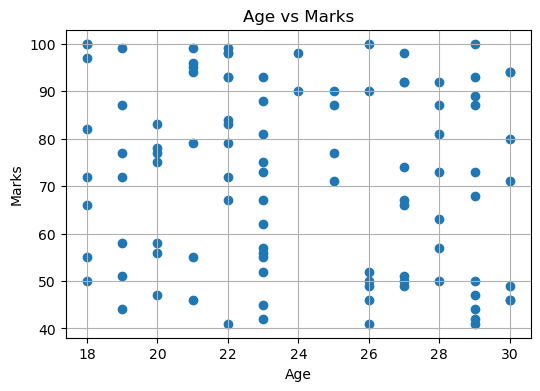

In [13]:
# chart 3
plt.figure(figsize=(6,4))
plt.scatter(df["Age"], df["Marks"])
plt.title("Age vs Marks")
plt.xlabel("Age")
plt.ylabel("Marks")
plt.grid(True)
plt.show()